# 1 Import Packages

In [1]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pan

# Create Air Mixture Object
air = ct.Solution('gri30.yaml')

# Create Air Fuel Mixture for Combustion Reaction
fuel1 = ct.Solution('gri30.yaml')

# 2 Stage 1 To Stage 6 Turbine

In [2]:
# Define Inlet Conditions to Compressor
P1 = 100000  # Pa (standard pressure)
T1 = 298  # K (standard temperature)

# Compressor Efficiency
Isen_Eff_Comp = 0.90

# Atomic Properties and Mole Fractions and Stoichiometric Combustion Parameters
CH4_Molecular_Weight=12.011+(4*(1.00784)) # Methane Molecular Weight
H2_Molecular_Weight=2*(1.00784) # Hydrogen Molecular Weight
O2_Molecular_Weight=(2*(15.999)) # O2 Air Molecular Weight
N2_Molecular_Weight=(2*(14.0067)) # N2 Air Molecular Weight
CH4_fuel_stoic_mole=1.0
H2_fuel_stoic_mole=1.0
O2_air_stoic_CH4_mole=2.0
O2_air_stoic_H2_mole=0.5
O2_air_vol_mole_fraction=0.21
N2_air_vol_mole_fraction=0.79

# Calculate Mass of Fuel and Air for Stoichiometric Air-Fuel Ratio. Separate Stoichiometric Reactions CH4 + 2O2 -> CO2 + 2H2O and H2 + 0.5O2 -> H2O
mole_CH4_only_stoic_reaction=1.0
mole_H2_only_stoic_reaction=1.0
CH4_stoic_mass = mole_CH4_only_stoic_reaction * CH4_Molecular_Weight
H2_stoic_mass = mole_H2_only_stoic_reaction * H2_Molecular_Weight

O2_in_air_mole_stoic_CH4_H2_separately_combined = CH4_fuel_stoic_mole * O2_air_stoic_CH4_mole + H2_fuel_stoic_mole * O2_air_stoic_H2_mole
air_total_mole_per_fuel = O2_in_air_mole_stoic_CH4_H2_separately_combined / O2_air_vol_mole_fraction
mass_air_stoic_CH4_H2_separately_combined = air_total_mole_per_fuel * (O2_air_vol_mole_fraction * O2_Molecular_Weight + N2_air_vol_mole_fraction * N2_Molecular_Weight)

CH4_H2_air_stoic_ratio = (CH4_stoic_mass + H2_stoic_mass)/mass_air_stoic_CH4_H2_separately_combined

# For Plots
equi_phi_vals = []
T3_vals = []
T3_Actual_vals = []
Cycle_Eff_vals = []
H2_Frac_vals = []
CH4_Frac_vals = []
Pressure_Ratio_vals = []
CO2_mole_fraction_vals = []
N2_mole_fraction_vals = []
NOx_mole_fraction_vals = []
#SOX_mole_fraction_vals = []
H2O_mole_fraction_vals = []
CO2_mass_fraction_vals = []
N2_mass_fraction_vals = []
NOx_mass_fraction_vals = []
#SOx_mass_fraction_vals = []
H2O_mass_fraction_vals = []
Compressor_Work_vals = []
Cooling_Air_Mass_vals = []
Heat_in_vals = []
Turbine_Work_vals = []
Net_Work_vals = []

# Loop over Compressor Pressure Ratio (10 to 20)
for PR in range (10,21,1):  # Pressure ratio from 10 to 20 in steps of 1

# Combustion in Combustion Chamber
    # Loop over Equivalence Ratio from 0 to 1 in steps of 0.1
    for equi_phi in np.arange (0.1,1.1,0.1):
        
        # Loop over Hydrogen Percentage (0% to 100%)
        for H2_frac in np.arange (0,1.1,0.1):  # Hydrogen fraction from 0% to 100% in steps of 10%
            CH4_frac = 1 - H2_frac  # Adjust methane fraction

            # Define fuel mole fractions
            fuel_mole_fraction = {'CH4': CH4_frac, 'H2': H2_frac}
            
            # Set fuel-air mixture
            air_mole_fractions = {'O2': 0.21, 'N2': 0.79}

            # Set Compressor Inlet State
            air.TPX=T1,P1, air_mole_fractions

            H1 = air.enthalpy_mass
            S1 = air.entropy_mass
            
            # Isentropic Compression from P1 to P2
            P2 = P1*PR
            S2 = S1
            air.SP = S2, P2
            T2s = air.T

            # Find Specific Heat Capacity at Constant Pressure for Air for Computing Heat Gain By Cooling Air in Else Loop When T3 is Higher than T3_Max
            Air_Spec_Capacity_Cp = air.cp_mass

            # Isentropic Enthalpy After Compression
            H2s = air.enthalpy_mass

            # Actual Enthalpy After Compression
            H2 = H1 + ((H2s-H1)/Isen_Eff_Comp)
            print('H2', H2)

            # Set State of Air With Actual Enthalpy H2
            air.HP = H2, P2
            T2 = air.T

            # Find Mass of Fuel Using Mole Fraction From Actual Specified CH4_frac-H2_frac Volume Fraction Loop
            mass_of_CH4 = CH4_frac * CH4_Molecular_Weight

            mass_of_H2 = H2_frac * H2_Molecular_Weight

            mass_fuel = mass_of_CH4 + mass_of_H2
  
            # Mass of Air From Compressor for Combustion 
            Comp_Mass_Air = mass_fuel/(equi_phi*CH4_H2_air_stoic_ratio) # Mass of Air Compressed by Compressor for Combustion [kg]

            # If Combustor Exhaust Temperature is Lower Than The Maximum Turbine Inlet Temperature No Turbine Cooling
            mass_cooling_air = 0

            # Create New Air Fuel Mixture for Combustion Reaction
            fuel1 = ct.Solution('gri30.yaml')

            # Set Mixture Temperature and Pressure To Premix Air and Fuel
            fuel1.TP=T2, P2

            # Simulate the Combustion to Calculate Temperature, T3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy of Air-Fuel Mixture at Compressor Temperature and Pressure
            H2constH2 = fuel1.enthalpy_mass
            print('H2 Constant Enthalpy', H2constH2)

            # Combust the Air-Fuel Mixture At Constant Enthalpy To Obtain Combustion Gases Temperature T3
            fuel1.equilibrate('HP')

            # Find Mole Fractions of Reaction Products:CO2, H2O, N2, NOx and SOx Formation Before Cooling            
            mole_fraction_CO2_Before_Cooling = fuel1['CO2'].X[0]
            mole_fraction_N2_Before_Cooling = fuel1['N2'].X[0]
            mole_fraction_H2O_Before_Cooling = fuel1['H2O'].X[0]
            mole_fraction_NO_Before_Cooling = fuel1['NO'].X[0]
            mole_fraction_NO2_Before_Cooling = fuel1['NO2'].X[0]
            mole_fraction_NOx_Before_Cooling = mole_fraction_NO_Before_Cooling + mole_fraction_NO2_Before_Cooling
            
            #mole_fraction_SO2 = fuel1['SO2'].X[0]
            #mole_fraction_SO3 = fuel1['SO3'].X[0]
            #mole_fraction_SOx = mole_fraction_SO2 + mole_fraction_SO3

            mass_fraction_CO2_Before_Cooling = fuel1['CO2'].Y[0]
            mass_fraction_N2_Before_Cooling = fuel1['N2'].Y[0]
            mass_fraction_H2O_Before_Cooling = fuel1['H2O'].Y[0]
            mass_fraction_NO_Before_Cooling = fuel1['NO'].Y[0]
            mass_fraction_NO2_Before_Cooling = fuel1['NO2'].Y[0]
            mass_fraction_NOx_Before_Cooling = mass_fraction_NO_Before_Cooling + mass_fraction_NO2_Before_Cooling

            #mass_fraction_SO2 = fuel1['SO2'].Y[0]
            #mass_fraction_SO3 = fuel1['SO3'].Y[0]
            #mass_fraction_SOx = mass_fraction_SO2 + mass_fraction_SO3

            # Adiabetic Flame Temperature
            T3 = fuel1.T 

            # Equlibrate at T3, Adiabetic Flame Temperature To Get Heat Added by Combustion
            # Set Mixture Temperature and Pressure of Premix Air and Fuel to Adiabetic flame Temperature, T3 and P2
            fuel1.TP=T3, P2

            # Simulate the Combustion to Calculate Enthalpy, H3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy and Entropy After Combustion at T3 and P2.
            H3 = fuel1.enthalpy_mass
            print('H3',H3)            
            S3 = fuel1.entropy_mass

            T3_Max = 2000 # Maximum Turbine Inlet Temperature. Calculate Cooling Air if T3 Exceeds T3_Max
            mass_cooling_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Below Maximum Turbine Inlet Temperature
            if T3<=T3_Max:
                #Actual T3 Values for Analysis
                T3_Actual=T3                

                # Calculate Compressor Air for Combustion
                mass_cooling_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max
                mass_fuel_air_in_combustor_turbine = Comp_Mass_Air + mass_cooling_air + mass_fuel # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                # Compressor Work With Air Flow Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Compute Heat Added
                Heat_in=mass_fuel_air_in_combustor_turbine*(H3-H2)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency
                
                # Reset the Combustion Mixture in the Turbine to S3 and P1, Exhaust Pressure             
                S4 = S3
                fuel1.SP = S4, P1
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3 - Isen_Eff_Turb * (H3 - H4s)   

                # Turbine Work
                W_Turb = mass_fuel_air_in_combustor_turbine*Isen_Eff_Turb*(H3-H4)

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

                # Mole Fractions of Reaction Products Same As Above Because No Recombustion To Account for Turbine Cooling 

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Above Maximum Turbine Inlet Temperature
            elif T3>T3_Max:
                # If T3 > T3_Max, Then Cool The Combustion Gases. H2 of Compresssed Air Remains the Same. Stoichiometric Air-Fuel Ratio Also Remains the Same Because Combustion has Already Occured, the Extra Air is Just for Cooling
                # Solve for Cooling Air Mass That Is Heated From T3_Max to T3, Temperature Above T3_Max. This Is Equal To Energy Gained By Cooling Air To Cool The Combustion Gas from Temperature T3, Above T3_Max to T3_Max
                H_Above_T3_Max = H3

                # Set Combusted Mixture To T3_Max and P2 for Calculating Difference in Enthalpy from H_Above_T3_Max and H3_Max
                fuel1.TP=T3_Max, P2

                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                H3_Max = fuel1.enthalpy_mass # Target Enthalpy
                S3_Max = fuel1.entropy_mass
                print('H3_Max', H3_Max)

                # Find Mass of Cooling Air From Change in Enthalpy of Cooling Air Which is Cooled at Constant Pressure i.e. H_Cooling=mass_cooling_air*cp(T3-T3_Max)
                H_Cooling_Energy = H_Above_T3_Max - H3_Max
                mass_cooling_air = H_Cooling_Energy/(Air_Spec_Capacity_Cp*(T3-T3_Max))

                # New Compressor Air with Cooling Air
                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air

                mass_fuel_air_cooling_air_in_turbine = mass_fuel + Comp_Mass_Air_Cooling # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Mass of Fuel and Combustion Air From Compressor for Heat_In Calculation
                mass_fuel_air_in_combustor = Comp_Mass_Air + mass_fuel # mass_cool is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Not Recombusting. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reducing the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                Heat_in = mass_fuel_air_in_combustor*(H3-H2)

                #Actual T3 Values for Analysis
                T3_Actual=T3

                # Set T3 to T3_Max for Plotting T3 Values
                T3=T3_Max

                # Compressor Work With Cooling Air Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency  

                # Set Combusted Mixture To S3_Max at Lower Energy Level of Cooled Combustion Gases Before Entering Turbine and Atmospheric Pressure, P1 for Expansion in Turbine                              
                S4 = S3_Max

                fuel1.SP = S4, P1

                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3_Max - Isen_Eff_Turb*(H3_Max-H4s)

                # Turbine Work. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reduce the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                W_Turb = mass_fuel_air_cooling_air_in_turbine*Isen_Eff_Turb*(H3_Max-H4)                

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in
 
            else:
                print("Error T3 is Not Positive")

            equi_phi_vals.append(equi_phi)
            T3_vals.append(T3)
            T3_Actual_vals.append(T3_Actual)            
            Cycle_Eff_vals.append(Cycle_Eff)
            H2_Frac_vals.append(H2_frac)
            CH4_Frac_vals.append(CH4_frac)
            Pressure_Ratio_vals.append(PR)
            CO2_mole_fraction_vals.append(mole_fraction_CO2_Before_Cooling)
            N2_mole_fraction_vals.append(mole_fraction_N2_Before_Cooling)
            NOx_mole_fraction_vals.append(mole_fraction_NOx_Before_Cooling)
            #SOX_mole_fraction_vals.append(mole_fraction_SOx_Before_Cooling)
            H2O_mole_fraction_vals.append(mole_fraction_H2O_Before_Cooling)
            CO2_mass_fraction_vals.append(mass_fraction_CO2_Before_Cooling)
            N2_mass_fraction_vals.append(mass_fraction_N2_Before_Cooling)
            NOx_mass_fraction_vals.append(mass_fraction_NOx_Before_Cooling)
            #SOx_mass_fraction_vals.append(mass_fraction_SOx_Before_Cooling)       
            H2O_mass_fraction_vals.append(mass_fraction_H2O_Before_Cooling)
            Compressor_Work_vals.append(W_Comp)
            Cooling_Air_Mass_vals.append(Comp_Mass_Air_Cooling)
            Heat_in_vals.append(Heat_in)
            Turbine_Work_vals.append(W_Turb)
            Net_Work_vals.append(Net_Work)

H2 309472.35704343393
H2 Constant Enthalpy 285419.42703731963
H3 575046.2617176487
H2 309472.35704343393
H2 Constant Enthalpy 286386.57108336943
H3 577867.899510913
H2 309472.35704343393
H2 Constant Enthalpy 287524.5808721629
H3 581188.995788579
H2 309472.35704343393
H2 Constant Enthalpy 288883.1242023197
H3 585155.0317271524
H2 309472.35704343393
H2 Constant Enthalpy 290533.1843478821
H3 589974.0599712357
H2 309472.35704343393
H2 Constant Enthalpy 292579.86904735863
H3 595954.3939870452
H2 309472.35704343393
H2 Constant Enthalpy 295185.71792643366
H3 603573.2672227357
H2 309472.35704343393
H2 Constant Enthalpy 298616.13542005676
H3 613610.8575513628
H2 309472.35704343393
H2 Constant Enthalpy 303336.05887871986
H3 627435.9510948578
H2 309472.35704343393
H2 Constant Enthalpy 310240.8719499762
H3 647689.8448138199
H2 309472.35704343393
H2 Constant Enthalpy 321304.5666583287
H3 680211.7646743132
H2 309472.35704343393
H2 Constant Enthalpy 261644.13274305145
H3 838371.1815912928
H2 309472.3

# Plot Graphs

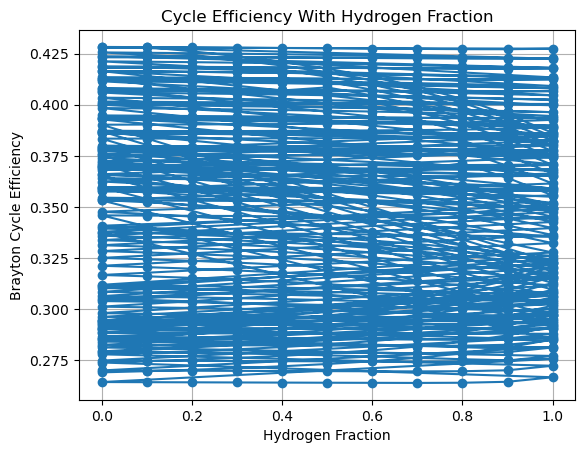

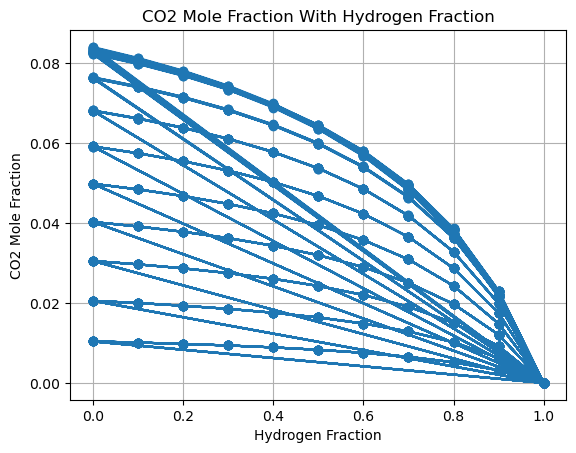

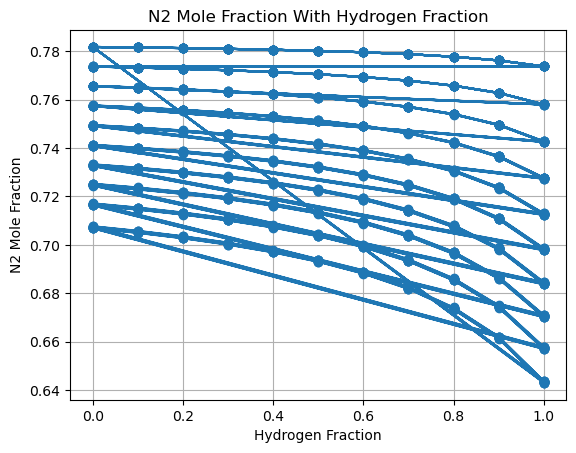

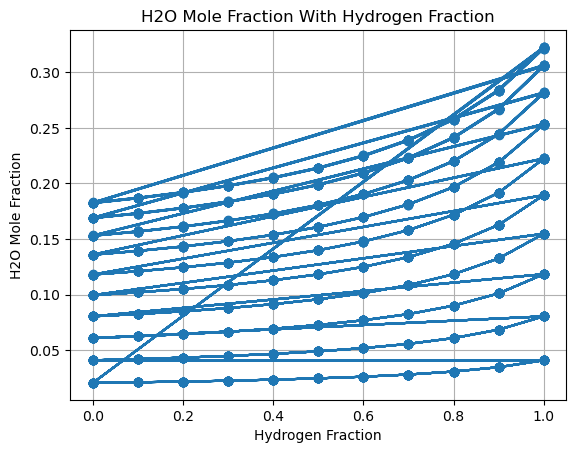

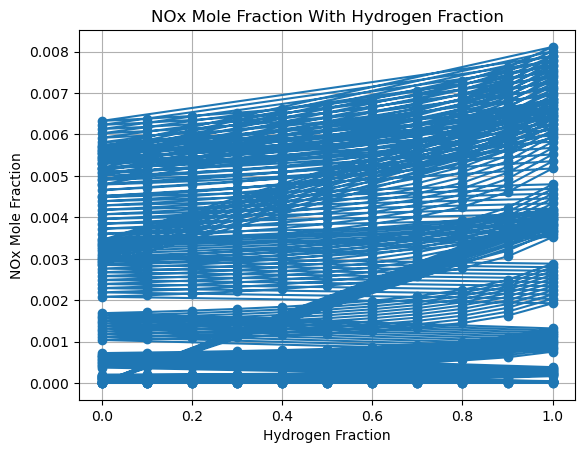

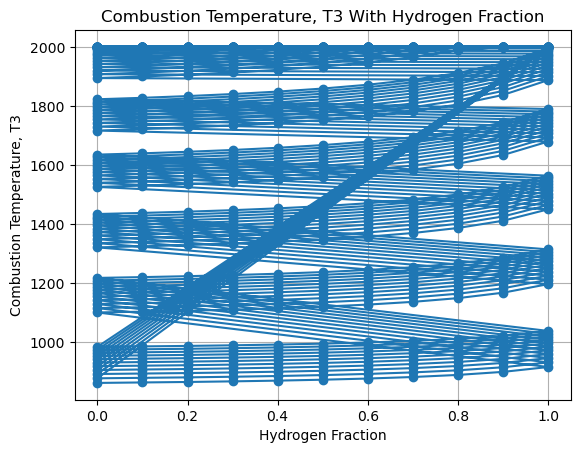

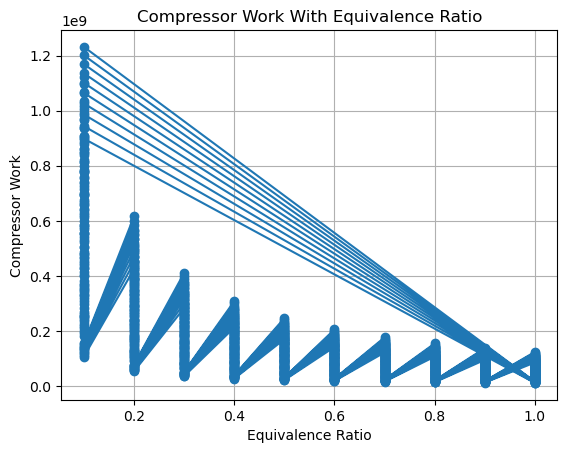

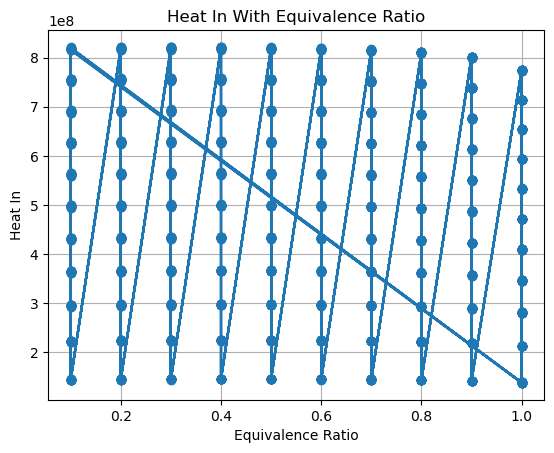

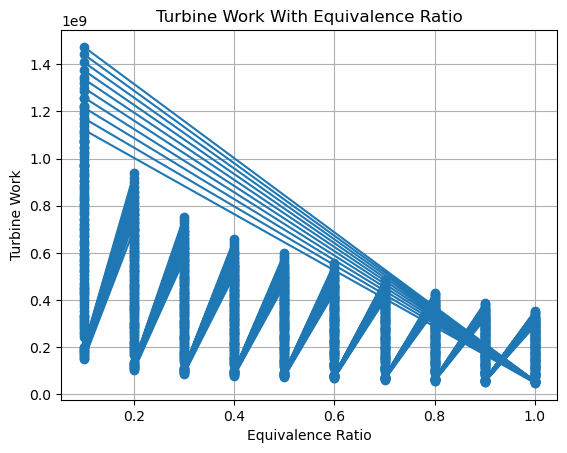

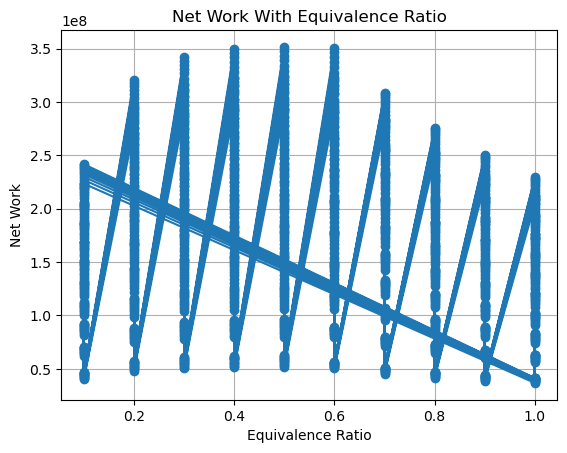

In [4]:
Loop_PR_Equi_CH4Frac = [Pressure_Ratio_vals, equi_phi_vals, CH4_Frac_vals, T3_vals, T3_Actual_vals, Compressor_Work_vals, Cooling_Air_Mass_vals, Heat_in_vals, Turbine_Work_vals, Net_Work_vals, Cycle_Eff_vals, CO2_mole_fraction_vals, NOx_mole_fraction_vals, H2O_mole_fraction_vals, CO2_mass_fraction_vals, NOx_mass_fraction_vals, H2O_mass_fraction_vals, N2_mole_fraction_vals, N2_mass_fraction_vals]
np.savetxt('All_H2_Values-GRI.csv', Loop_PR_Equi_CH4Frac, delimiter=",", fmt='%s')

plt.figure(1)
plt.plot(H2_Frac_vals, Cycle_Eff_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('Brayton Cycle Efficiency')
plt.title('Cycle Efficiency With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(2)
plt.plot(H2_Frac_vals, CO2_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('CO2 Mole Fraction')
plt.title('CO2 Mole Fraction With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(3)
plt.plot(H2_Frac_vals, N2_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('N2 Mole Fraction')
plt.title('N2 Mole Fraction With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(4)
plt.plot(H2_Frac_vals, H2O_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('H2O Mole Fraction')
plt.title('H2O Mole Fraction With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(5)
plt.plot(H2_Frac_vals, NOx_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('NOx Mole Fraction')
plt.title('NOx Mole Fraction With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(6)
plt.plot(H2_Frac_vals, T3_vals, marker='o', linestyle='-')
plt.xlabel('Hydrogen Fraction')
plt.ylabel('Combustion Temperature, T3')
plt.title('Combustion Temperature, T3 With Hydrogen Fraction')
plt.grid()
plt.show()

plt.figure(7)
plt.plot(equi_phi_vals, Compressor_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Compressor Work')
plt.title('Compressor Work With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(8)
plt.plot(equi_phi_vals, Heat_in_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Heat In')
plt.title('Heat In With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(9)
plt.plot(equi_phi_vals, Turbine_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Turbine Work')
plt.title('Turbine Work With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(10)
plt.plot(equi_phi_vals, Net_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Net Work')
plt.title('Net Work With Equivalence Ratio')
plt.grid()
plt.show()

# plt.figure(7)
# plt.plot(H2_Frac_vals, SOX_mole_fraction_vals, marker='o', linestyle='-')
# plt.xlabel('Hydrogen Fraction')
# plt.ylabel('SOx Mole Fraction')
# plt.title('SOx Mole Fraction With Hydrogen Fraction')
# plt.grid()
# plt.show()